# HATR BSD10k Colab 5-Fold Training

이 노트북은 `https://github.com/allholy/hatr.git`의 HATR 코드를 Colab에서 실행하도록 구성합니다.

- metadata: `/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv`
- audio embeddings: `/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings`
- text embeddings: `/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings`
- 마지막 셀에서 fold별 confusion matrix의 평균과 표준편차를 `mean ± std` 형태로 확인합니다.


In [1]:
# 1. Drive mount, package install, HATR clone
from google.colab import drive
drive.mount('/content/drive')

import os
import subprocess
import sys

!pip -q install numpy pandas scikit-learn matplotlib seaborn PyYAML tqdm

REPO_URL = "https://github.com/allholy/hatr.git"
HATR_DIR = "/content/hatr"

if not os.path.isdir(HATR_DIR):
    subprocess.run(["git", "clone", REPO_URL, HATR_DIR], check=True)
else:
    print(f"HATR repo already exists: {HATR_DIR}")

if HATR_DIR not in sys.path:
    sys.path.insert(0, HATR_DIR)

print("HATR_DIR:", HATR_DIR)


Mounted at /content/drive
HATR_DIR: /content/hatr


In [2]:
# 2. Dataset paths and experiment settings
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

METADATA_CSV = "/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv"
DRIVE_AUDIO_EMB_DIR = "/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings"
DRIVE_TEXT_EMB_DIR  = "/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings"

# Copy Drive embeddings to Colab local disk first. Direct per-batch np.load from Drive is very slow.
LOCAL_BASE_DIR = "/content/bsd10k_features_hatr"
AUDIO_EMB_DIR = f"{LOCAL_BASE_DIR}/clap_audio_embeddings"
TEXT_EMB_DIR = f"{LOCAL_BASE_DIR}/clap_text_embeddings"

PROJECT_DIR = "/content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab"
OUTPUT_DATA_DIR = f"{PROJECT_DIR}/data"
MODEL_OUTPUT_DIR = f"{PROJECT_DIR}/model_output"
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

SEED = 1821
N_FOLDS = 5
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 5
EARLY_STOPPING_FACTOR = 3
MODE = "both"  # "audio", "text", or "both"
CONFIDENCE_MIN = 0  # BSD10k_metadata.csv의 confidence 필터. 전체 사용이면 None으로 변경.

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
def copy_drive_features_to_local():
    Path(LOCAL_BASE_DIR).mkdir(parents=True, exist_ok=True)
    for src, dst in [(DRIVE_AUDIO_EMB_DIR, AUDIO_EMB_DIR), (DRIVE_TEXT_EMB_DIR, TEXT_EMB_DIR)]:
        if Path(dst).is_dir() and any(Path(dst).glob("*.npy")):
            print(f"Already copied: {dst}")
        else:
            print(f"Copying {src} -> {dst}")
            shutil.copytree(src, dst, dirs_exist_ok=True)

print("Output:", PROJECT_DIR)


Output: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab


In [3]:
# 3. Write HATR config.yaml for Colab paths
config = {
    "active_dataset": "BSD10k-v1.2",
    "datasets": {
        "BSD10k-v1.2": {
            "metadata_csv": METADATA_CSV,
            "audio_emb_folder": AUDIO_EMB_DIR,
            "text_emb_folder": TEXT_EMB_DIR,
            "class_names": "",
        }
    },
    "color_dict_path": f"{HATR_DIR}/data/bst_colours.json",
    "top_color_dict_path": f"{HATR_DIR}/data/bst_colours.json",
    "output_path": OUTPUT_DATA_DIR,
    "processed_dataset_csv": "processed_dataset.csv",
    "class_dict_json": "class_dict.json",
    "top_class_dict_json": "top_class_dict.json",
    "top_class_subclass_dict_json": "top_class_subclass_dict.json",
}

with open(f"{HATR_DIR}/config.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=False, allow_unicode=True)

print(open(f"{HATR_DIR}/config.yaml", encoding="utf-8").read())


active_dataset: BSD10k-v1.2
datasets:
  BSD10k-v1.2:
    metadata_csv: /content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv
    audio_emb_folder: /content/bsd10k_features_hatr/clap_audio_embeddings
    text_emb_folder: /content/bsd10k_features_hatr/clap_text_embeddings
    class_names: ''
color_dict_path: /content/hatr/data/bst_colours.json
top_color_dict_path: /content/hatr/data/bst_colours.json
output_path: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/data
processed_dataset_csv: processed_dataset.csv
class_dict_json: class_dict.json
top_class_dict_json: top_class_dict.json
top_class_subclass_dict_json: top_class_subclass_dict.json



In [4]:
# 4. Build processed HATR dataset from metadata + .npy embeddings
import subprocess
import sys

copy_drive_features_to_local()

subprocess.run([sys.executable, "build_dataset_full.py"], cwd=HATR_DIR, check=True)

PROCESSED_CSV = f"{OUTPUT_DATA_DIR}/processed_dataset.csv"
CLASS_DICT_JSON = f"{OUTPUT_DATA_DIR}/class_dict.json"
TOP_CLASS_DICT_JSON = f"{OUTPUT_DATA_DIR}/top_class_dict.json"

full_df = pd.read_csv(PROCESSED_CSV)
metadata_df = pd.read_csv(METADATA_CSV)

full_df["index"] = full_df["index"].astype(str)
metadata_df["sound_id"] = metadata_df["sound_id"].astype(str)

if CONFIDENCE_MIN is not None and "confidence" in metadata_df.columns:
    keep_ids = metadata_df.loc[metadata_df["confidence"] >= CONFIDENCE_MIN, "sound_id"]
    full_df = full_df[full_df["index"].isin(set(keep_ids))].reset_index(drop=True)

print("Processed rows:", len(full_df))
print("Classes:", full_df["class_idx"].nunique())
display(full_df.head())


Copying /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings -> /content/bsd10k_features_hatr/clap_audio_embeddings
Copying /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings -> /content/bsd10k_features_hatr/clap_text_embeddings
Processed rows: 10956
Classes: 23


,index,audio_emb_filepath,text_emb_filepath,top_class,top_class_idx,class,class_idx
0,185755,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,fx,3,fx-o,11
1,358405,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,is,1,is-w,5
2,358760,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,is,1,is-w,5
3,432206,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,fx,3,fx-o,11
4,80630,/content/bsd10k_features_hatr/clap_audio_embed...,/content/bsd10k_features_hatr/clap_text_embedd...,sp,2,sp-s,8


In [5]:
# 5. Imports and HATR helper functions
import collections
from collections import defaultdict

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dataset_utils import HATRDataset
from losses import CrossEntropyLoss, HierarchicalContrastiveLoss, TopClassLoss
from models import BaseClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

with open(CLASS_DICT_JSON, encoding="utf-8") as f:
    class_dict = json.load(f)
with open(TOP_CLASS_DICT_JSON, encoding="utf-8") as f:
    top_class_dict = json.load(f)

id_to_class = {int(v): k for k, v in class_dict.items()}
class_names = [id_to_class[i] for i in range(len(id_to_class))]

def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

def build_class_to_top_class_mapping(class_dict, top_class_dict):
    class_to_top = {}
    for class_name, class_id in class_dict.items():
        top_name = class_name.split("-")[0]
        class_to_top[int(class_id)] = int(top_class_dict[top_name])
    return class_to_top

def build_subclass_to_topclass_tensor(class_dict, top_class_dict, device):
    class_to_top = build_class_to_top_class_mapping(class_dict, top_class_dict)
    tensor = torch.zeros(len(class_dict), dtype=torch.long, device=device)
    for class_id, top_id in class_to_top.items():
        tensor[class_id] = top_id
    return tensor

class_to_top_class = build_class_to_top_class_mapping(class_dict, top_class_dict)
subclass_to_topclass = build_subclass_to_topclass_tensor(class_dict, top_class_dict, device)


Device: cuda


In [6]:
# 6. Train/evaluate functions
def make_loaders(train_df, val_df, test_df):
    train_ds = HATRDataset(train_df, aug=True, mask_pct=0.7)
    val_ds = HATRDataset(val_df, aug=False)
    test_ds = HATRDataset(test_df, aug=False)
    # Colab + Drive/local npy loading is more stable with num_workers=0.
    common = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, val_loader, test_loader

def make_model():
    emb_size_audio = 512 if MODE in ["audio", "both"] else 0
    emb_size_text = 512 if MODE in ["text", "both"] else 0
    model = BaseClassifier(
        hidden_size=128,
        num_classes=len(class_dict),
        emb_size_audio=emb_size_audio,
        emb_size_text=emb_size_text,
        dropout=0.1,
        use_batch_norm=True,
        mode=MODE,
    ).to(device)
    model.apply(init_weights)
    return model

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    ce_loss = CrossEntropyLoss()
    top_loss = TopClassLoss(class_to_top_class, penalty_weight=1.0)
    contrastive_loss = HierarchicalContrastiveLoss(subclass_to_topclass=subclass_to_topclass)
    total_loss = 0.0
    y_true, y_pred = [], []

    for batch in loader:
        labels = batch["class_idx"].long().to(device)
        audio = batch.get("audio_embedding")
        text = batch.get("text_embedding")
        audio = audio.to(device) if audio is not None else None
        text = text.to(device) if text is not None else None

        with torch.set_grad_enabled(is_train):
            z, logits, _ = model(audio, text)
            loss = ce_loss(logits, labels)
            loss = loss + 1.0 * top_loss(logits, labels)
            loss = loss + 0.3 * contrastive_loss(z, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += float(loss.detach().cpu()) * labels.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(y_true))
    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    return avg_loss, acc, np.array(y_true), np.array(y_pred)

def train_one_fold(fold, train_df, val_df, test_df):
    fold_dir = f"{MODEL_OUTPUT_DIR}/fold_{fold}"
    os.makedirs(fold_dir, exist_ok=True)
    best_path = f"{fold_dir}/best_model.pth"

    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    best_val_acc = -1.0
    stale_epochs = 0
    history = []

    for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc=f"Fold {fold}"):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, optimizer=None)
        scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            stale_epochs = 0
            torch.save(model.state_dict(), best_path)
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % 5 == 0:
            print(f"fold={fold} epoch={epoch:03d} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if stale_epochs >= PATIENCE * EARLY_STOPPING_FACTOR:
            print(f"Fold {fold}: early stopping at epoch {epoch}")
            break

    pd.DataFrame(history).to_csv(f"{fold_dir}/history.csv", index=False)
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, optimizer=None)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_dict))))
    np.save(f"{fold_dir}/confusion_matrix.npy", cm)
    pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(f"{fold_dir}/predictions.csv", index=False)

    print(f"Fold {fold} done: best_val_acc={best_val_acc:.4f}, test_acc={test_acc:.4f}")
    return {"fold": fold, "best_val_acc": best_val_acc, "test_acc": test_acc, "cm": cm}


In [7]:
# 7. Run stratified K-fold training
labels = full_df["class_idx"].astype(int).to_numpy()
class_counts = pd.Series(labels).value_counts()
effective_folds = min(N_FOLDS, int(class_counts.min()))

if effective_folds < 2:
    raise ValueError("At least two samples per class are required for stratified K-fold.")
if effective_folds != N_FOLDS:
    print(f"N_FOLDS changed from {N_FOLDS} to {effective_folds} because the rarest class has {class_counts.min()} samples.")

skf = StratifiedKFold(n_splits=effective_folds, shuffle=True, random_state=SEED)
fold_results = []

for fold, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
    trainval_labels = labels[trainval_idx]
    val_fraction = max(0.2, (len(np.unique(trainval_labels)) + 1) / len(trainval_labels))
    if val_fraction >= 0.5:
        print(f"Large validation fraction required for stratification: {val_fraction:.3f}")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=SEED + fold)
    train_rel, val_rel = next(sss.split(np.zeros(len(trainval_labels)), trainval_labels))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel]

    train_df = full_df.iloc[train_idx].reset_index(drop=True)
    val_df = full_df.iloc[val_idx].reset_index(drop=True)
    test_df = full_df.iloc[test_idx].reset_index(drop=True)

    print(f"\n==== Fold {fold}/{effective_folds} ====")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    fold_results.append(train_one_fold(fold, train_df, val_df, test_df))

summary = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in fold_results])
summary.to_csv(f"{MODEL_OUTPUT_DIR}/fold_summary.csv", index=False)
display(summary)
print(f"Mean test accuracy: {summary['test_acc'].mean():.4f} ± {summary['test_acc'].std(ddof=0):.4f}")



==== Fold 1/5 ====
Train: 7011, Val: 1753, Test: 2192


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

fold=1 epoch=001 train_acc=0.2739 val_acc=0.5670
fold=1 epoch=005 train_acc=0.7291 val_acc=0.7564
fold=1 epoch=010 train_acc=0.7921 val_acc=0.7798
fold=1 epoch=015 train_acc=0.8291 val_acc=0.7884
fold=1 epoch=020 train_acc=0.8415 val_acc=0.7878
fold=1 epoch=025 train_acc=0.8830 val_acc=0.7975
fold=1 epoch=030 train_acc=0.8928 val_acc=0.7827
Fold 1: early stopping at epoch 31
Fold 1 done: best_val_acc=0.7986, test_acc=0.7911

==== Fold 2/5 ====
Train: 7012, Val: 1753, Test: 2191


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

fold=2 epoch=001 train_acc=0.3036 val_acc=0.6070
fold=2 epoch=005 train_acc=0.7291 val_acc=0.7604
fold=2 epoch=010 train_acc=0.7933 val_acc=0.7832
fold=2 epoch=015 train_acc=0.8129 val_acc=0.7872
fold=2 epoch=020 train_acc=0.8440 val_acc=0.7895
fold=2 epoch=025 train_acc=0.8776 val_acc=0.7827
fold=2 epoch=030 train_acc=0.8898 val_acc=0.7895
fold=2 epoch=035 train_acc=0.8984 val_acc=0.7724
fold=2 epoch=040 train_acc=0.9156 val_acc=0.7798
fold=2 epoch=045 train_acc=0.9375 val_acc=0.7872
fold=2 epoch=050 train_acc=0.9450 val_acc=0.7878
Fold 2: early stopping at epoch 51
Fold 2 done: best_val_acc=0.7952, test_acc=0.7987

==== Fold 3/5 ====
Train: 7012, Val: 1753, Test: 2191


...

fold=4 epoch=001 train_acc=0.3245 val_acc=0.6075
fold=4 epoch=005 train_acc=0.7408 val_acc=0.7661
fold=4 epoch=010 train_acc=0.7939 val_acc=0.7661
fold=4 epoch=015 train_acc=0.8136 val_acc=0.7906
fold=4 epoch=020 train_acc=0.8473 val_acc=0.7804
fold=4 epoch=025 train_acc=0.8823 val_acc=0.7827
fold=4 epoch=030 train_acc=0.8880 val_acc=0.7861
fold=4 epoch=035 train_acc=0.8958 val_acc=0.7764
Fold 4: early stopping at epoch 37
Fold 4 done: best_val_acc=0.8009, test_acc=0.8042

==== Fold 5/5 ====
Train: 7012, Val: 1753, Test: 2191


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

fold=5 epoch=001 train_acc=0.2901 val_acc=0.5402
fold=5 epoch=005 train_acc=0.7345 val_acc=0.7638
fold=5 epoch=010 train_acc=0.7980 val_acc=0.7992
fold=5 epoch=015 train_acc=0.8194 val_acc=0.8015
fold=5 epoch=020 train_acc=0.8420 val_acc=0.7878
fold=5 epoch=025 train_acc=0.8826 val_acc=0.8032
fold=5 epoch=030 train_acc=0.8873 val_acc=0.8038
fold=5 epoch=035 train_acc=0.9034 val_acc=0.7878
Fold 5: early stopping at epoch 37
Fold 5 done: best_val_acc=0.8146, test_acc=0.8060


,fold,best_val_acc,test_acc
0,1,0.798631,0.791058
1,2,0.795208,0.798722
2,3,0.819738,0.790963
3,4,0.800913,0.804199
4,5,0.814604,0.806025


Mean test accuracy: 0.7982 ± 0.0063


In [9]:
# Baseline-style metrics from saved fold predictions
import os
import numpy as np
import pandas as pd

def extend_subcat(label_name):
    parts = str(label_name).split("-")
    top = parts[0]
    sub = "-".join(parts[1:]) if len(parts) > 1 else ""
    return [top, sub]

def get_top_level(label_name):
    return str(label_name).split("-")[0]

def intersection(a, b):
    return list(set(a).intersection(set(b)))

def hierarchical_accuracy_for_class(subcat, prediction_gt_pairs, lambda_param=0.5):
    scores = []
    for prediction, gt in prediction_gt_pairs:
        if subcat == gt:
            pred_top, pred_sub = extend_subcat(prediction)
            gt_top, gt_sub = extend_subcat(gt)

            if pred_top == gt_top and pred_sub == gt_sub:
                scores.append(1.0)
            elif pred_top == gt_top and pred_sub != gt_sub:
                scores.append(lambda_param)
            else:
                scores.append(0.0)

    return np.mean(scores) if scores else np.nan

def hierarchical_prf_weighted_for_class(subcat, prediction_gt_pairs, lambda_param=0.75):
    hPP = []
    hRR = []

    for prediction, gt in prediction_gt_pairs:
        pi = extend_subcat(prediction)
        ti = extend_subcat(gt)
        pi_intersection_ti = intersection(pi, ti)

        if subcat == prediction:
            w = 1.0 if prediction == gt else (
                lambda_param if get_top_level(prediction) == get_top_level(gt) else 0.0
            )
            hP = (w * len(pi_intersection_ti)) / len(pi)
            hPP.append(hP)

        if subcat == gt:
            w = 1.0 if prediction == gt else (
                lambda_param if get_top_level(prediction) == get_top_level(gt) else 0.0
            )
            hR = (w * len(pi_intersection_ti)) / len(ti)
            hRR.append(hR)

    classP = np.mean(hPP) if hPP else np.nan
    classR = np.mean(hRR) if hRR else np.nan

    if np.isnan(classP) or np.isnan(classR):
        classF = np.nan
    elif classP == 0 and classR == 0:
        classF = 0.0
    else:
        classF = 2 * classP * classR / (classP + classR)

    return classP, classR, classF

def compute_baseline_style_metrics(y_true, y_pred, class_dict, class_to_top_class):
    id_to_class = {int(v): k for k, v in class_dict.items()}

    y_true = [int(x) for x in y_true]
    y_pred = [int(x) for x in y_pred]

    gt_labels = [id_to_class[x] for x in y_true]
    pred_labels = [id_to_class[x] for x in y_pred]
    prediction_gt_pairs = list(zip(pred_labels, gt_labels))
    classes = sorted(set(gt_labels))

    total = len(y_true)

    accuracy = np.mean(np.array(y_true) == np.array(y_pred))

    top_accuracy = np.mean([
        class_to_top_class.get(gt) == class_to_top_class.get(pred)
        for gt, pred in zip(y_true, y_pred)
    ])

    class_accs = []
    class_top_accs = []

    for c in sorted(set(y_true)):
        idx = [i for i, gt in enumerate(y_true) if gt == c]
        class_accs.append(np.mean([y_pred[i] == y_true[i] for i in idx]))
        class_top_accs.append(np.mean([
            class_to_top_class.get(y_true[i]) == class_to_top_class.get(y_pred[i])
            for i in idx
        ]))

    h_accs = []
    hPs, hRs, hFs = [], [], []

    for c in classes:
        h_acc = hierarchical_accuracy_for_class(c, prediction_gt_pairs, lambda_param=0.5)
        if not np.isnan(h_acc):
            h_accs.append(h_acc)

        hP, hR, hF = hierarchical_prf_weighted_for_class(
            c, prediction_gt_pairs, lambda_param=0.75
        )
        if not np.isnan(hP):
            hPs.append(hP)
        if not np.isnan(hR):
            hRs.append(hR)
        if not np.isnan(hF):
            hFs.append(hF)

    return {
        "accuracy": 100 * accuracy,
        "top_accuracy": 100 * top_accuracy,
        "macro_accuracy": 100 * np.mean(class_accs),
        "macro_top_accuracy": 100 * np.mean(class_top_accs),
        "hierarchical_accuracy": 100 * np.mean(h_accs),
        "hierarchical_precision": 100 * np.mean(hPs),
        "hierarchical_recall": 100 * np.mean(hRs),
        "hierarchical_f1": 100 * np.mean(hFs),
    }

metric_rows = []

for fold in range(1, effective_folds + 1):
    pred_path = f"{MODEL_OUTPUT_DIR}/fold_{fold}/predictions.csv"
    pred_df = pd.read_csv(pred_path)

    metrics = compute_baseline_style_metrics(
        y_true=pred_df["y_true"].values,
        y_pred=pred_df["y_pred"].values,
        class_dict=class_dict,
        class_to_top_class=class_to_top_class,
    )

    metrics["fold"] = fold
    metric_rows.append(metrics)

baseline_metrics_df = pd.DataFrame(metric_rows)
baseline_metrics_df = baseline_metrics_df[
    [
        "fold",
        "accuracy",
        "top_accuracy",
        "macro_accuracy",
        "macro_top_accuracy",
        "hierarchical_accuracy",
        "hierarchical_precision",
        "hierarchical_recall",
        "hierarchical_f1",
    ]
]

baseline_metrics_df.to_csv(
    f"{MODEL_OUTPUT_DIR}/baseline_style_fold_metrics.csv",
    index=False,
)

display(baseline_metrics_df)

mean_std = pd.DataFrame({
    "mean": baseline_metrics_df.drop(columns=["fold"]).mean(),
    "std": baseline_metrics_df.drop(columns=["fold"]).std(ddof=0),
})

mean_std["mean_pm_std"] = mean_std.apply(
    lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}",
    axis=1,
)

mean_std.to_csv(
    f"{MODEL_OUTPUT_DIR}/baseline_style_metrics_mean_std.csv"
)

display(mean_std)

,fold,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1
0,1,79.105839,88.640511,73.283408,84.278713,78.781061,76.569661,76.135745,75.855663
1,2,79.872204,89.502510,74.889105,85.830701,80.359903,78.565896,77.587521,77.954004
2,3,79.096303,88.863533,74.110313,85.128963,79.619638,77.736250,76.971403,77.022929
3,4,80.419900,88.954815,75.517113,85.296264,80.406689,78.195648,78.029404,77.865695
4,5,80.602465,89.091739,74.512775,85.066166,79.789470,79.331116,77.247470,77.697765


,mean,std,mean_pm_std
accuracy,79.819342,0.633816,79.82 ± 0.63
top_accuracy,89.010622,0.286449,89.01 ± 0.29
macro_accuracy,74.462543,0.749803,74.46 ± 0.75
macro_top_accuracy,85.120161,0.499381,85.12 ± 0.50
hierarchical_accuracy,79.791352,0.591957,79.79 ± 0.59
hierarchical_precision,78.079714,0.918047,78.08 ± 0.92
hierarchical_recall,77.194309,0.636407,77.19 ± 0.64
hierarchical_f1,77.279211,0.783156,77.28 ± 0.78


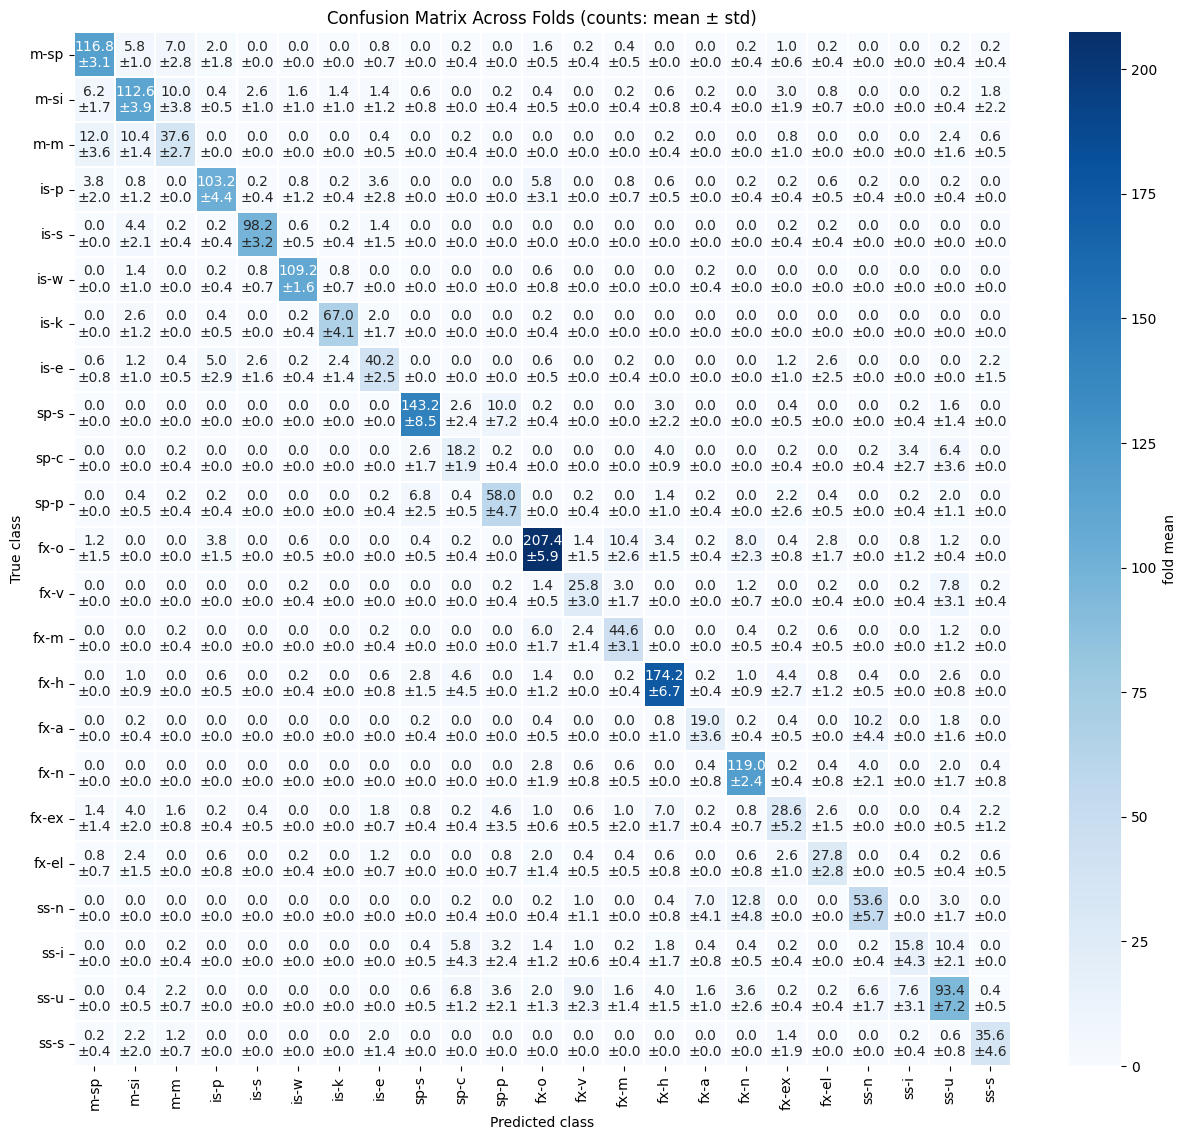

Saved: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/confusion_matrix_mean_pm_std_counts.png


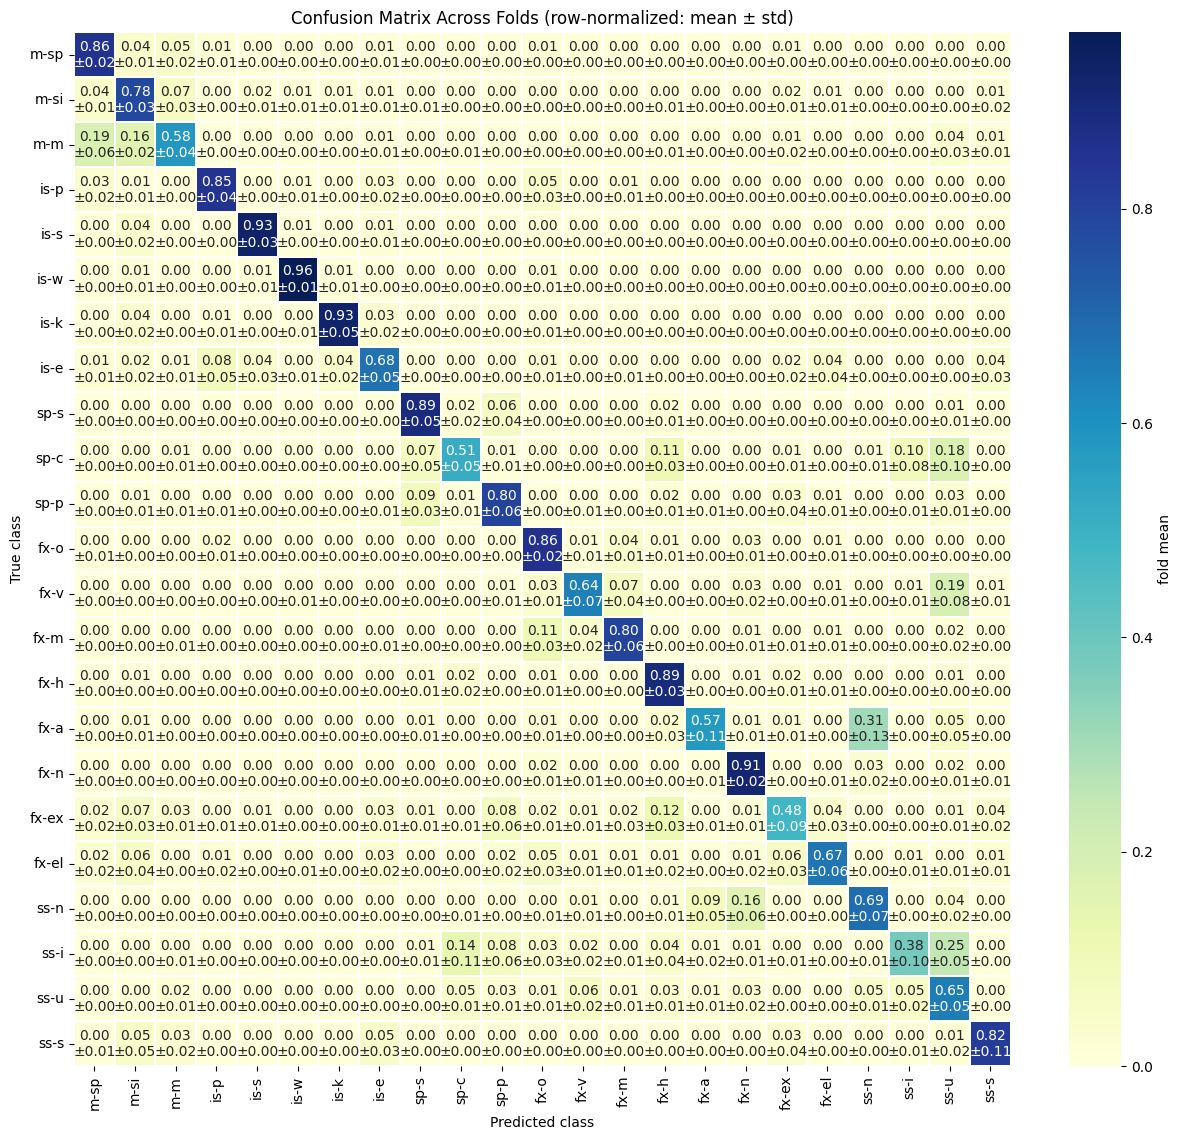

Saved: /content/drive/MyDrive/DCASE2026/hatr_bsd10k_colab/model_output/confusion_matrix_mean_pm_std_normalized.png


In [8]:
# 8. Fold mean ± std confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cms = np.stack([r["cm"] for r in fold_results], axis=0).astype(float)
cm_mean = cms.mean(axis=0)
cm_std = cms.std(axis=0, ddof=0)

row_sums = cms.sum(axis=2, keepdims=True)
cm_norms = np.divide(cms, row_sums, out=np.zeros_like(cms), where=row_sums != 0)
cm_norm_mean = cm_norms.mean(axis=0)
cm_norm_std = cm_norms.std(axis=0, ddof=0)

pd.DataFrame(cm_mean, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_mean_counts.csv")
pd.DataFrame(cm_std, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_std_counts.csv")
pd.DataFrame(cm_norm_mean, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_mean_normalized.csv")
pd.DataFrame(cm_norm_std, index=class_names, columns=class_names).to_csv(f"{MODEL_OUTPUT_DIR}/confusion_matrix_std_normalized.csv")

def plot_mean_pm_std(matrix_mean, matrix_std, title, value_fmt, save_name, cmap="Blues"):
    n = len(class_names)
    figsize = (max(10, n * 0.55), max(8, n * 0.50))
    annot = np.empty_like(matrix_mean, dtype=object)
    for i in range(n):
        for j in range(n):
            annot[i, j] = f"{format(matrix_mean[i, j], value_fmt)}\n±{format(matrix_std[i, j], value_fmt)}"

    plt.figure(figsize=figsize)
    sns.heatmap(
        matrix_mean,
        annot=annot,
        fmt="",
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "fold mean"},
        linewidths=0.2,
        linecolor="white",
    )
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_path = f"{MODEL_OUTPUT_DIR}/{save_name}"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_mean_pm_std(cm_mean, cm_std, "Confusion Matrix Across Folds (counts: mean ± std)", ".1f", "confusion_matrix_mean_pm_std_counts.png")
plot_mean_pm_std(cm_norm_mean, cm_norm_std, "Confusion Matrix Across Folds (row-normalized: mean ± std)", ".2f", "confusion_matrix_mean_pm_std_normalized.png", cmap="YlGnBu")
